## 1. Khởi tạo Môi trường và Cấu hình Tham số (Setup)

Cell này thực hiện việc nhập các thư viện cần thiết và thiết lập các biến toàn cục cho quá trình huấn luyện:

1.  **Thư viện phân tích dữ liệu & Đánh giá:**
    * `numpy`, `pandas`: Xử lý dữ liệu bảng và thao tác với đường dẫn ảnh.
    * `matplotlib`, `seaborn`: Trực quan hóa phân phối dữ liệu và biểu đồ huấn luyện.
    * `sklearn`: Sử dụng `StratifiedKFold` để chia dữ liệu thành 5 phần (5-fold) cân bằng tỉ lệ lớp, giúp đánh giá model khách quan.

2.  **Thư viện Deep Learning (TensorFlow/Keras):**
    * **Architecture:** Sử dụng kiến trúc **VGG16** (Transfer Learning) kết hợp `preprocess_input` để tận dụng đặc trưng từ ImageNet.
    * **Custom Layers:** Sử dụng `GlobalAveragePooling2D` để giảm chiều dữ liệu và `Dropout` để chống hiện tượng quá khớp (Overfitting).
    * **Callbacks:** `EarlyStopping` (dừng sớm), `ReduceLROnPlateau` (giảm tốc độ học khi bão hòa) và `ModelCheckpoint` (lưu model tốt nhất).

3.  **Cấu hình Siêu tham số (Hyperparameters):**
    * `IMG_WIDTH`, `IMG_HEIGHT`: **224x224** (Kích thước đầu vào chuẩn bắt buộc của VGG16).
    * `BATCH_SIZE`: **32** (Tăng tính ổn định cho quá trình cập nhật trọng số).
    * `EPOCHS`: **50** (Số vòng lặp huấn luyện tối đa).
    * `LEARNING_RATE`: **0.001** (Tốc độ học khởi tạo cho Optimizer Adam).

4.  **Thiết lập đường dẫn:** Code tự động kiểm tra môi trường chạy (Google Colab hoặc Local) để gắn (mount) Google Drive và trỏ đến thư mục dữ liệu chính xác.

In [1]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 50
NUM_FOLDS = 5
LEARNING_RATE = 0.001

try:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/AI_VGG16_Classifier'
    DATA_DIR = os.path.join(base_path, 'data/processed')
    MODELS_DIR = os.path.join(base_path, 'models')
except ImportError:
    print("Detected: LOCAL environment")
    DATA_DIR = '../data/processed'
    MODELS_DIR = '../models'
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)
    print(f"Đã tạo thư mục lưu model: {MODELS_DIR}")

Mounted at /content/drive


## 2. Tải và Tiền xử lý Dữ liệu (Data Loading & EDA)

Cell này thực hiện việc quét toàn bộ thư mục dữ liệu, gán nhãn tự động và kiểm tra phân bố của tập dữ liệu:

1.  **Thu thập dữ liệu ảnh:**
    * Sử dụng `pathlib` để quét đệ quy (recursive glob) tất cả các định dạng ảnh phổ biến (`.jpg`, `.png`, `.jpeg`) trong thư mục dữ liệu đã mount.
    
2.  **Gán nhãn và Cấu trúc hóa:**
    * **Trích xuất nhãn:** Tự động lấy tên thư mục cha của mỗi file ảnh làm nhãn lớp (Class Label).
    * **Tạo DataFrame:** Chuyển đổi dữ liệu thô thành bảng `pandas` với hai cột chính: `filename` (đường dẫn) và `class` (nhãn), giúp dễ dàng tích hợp với `ImageDataGenerator`.

3.  **Xử lý ngẫu nhiên (Shuffling):**
    * Thực hiện xáo trộn toàn bộ dataset (`frac=1`) với `random_state=42`. Bước này quan trọng để phá bỏ thứ tự sắp xếp mặc định của hệ điều hành, đảm bảo dữ liệu khi đưa vào huấn luyện được phân phối ngẫu nhiên.

4.  **Khám phá dữ liệu (EDA):**
    * In ra tổng số lượng ảnh và danh sách các lớp.
    * **Trực quan hóa:** Sử dụng biểu đồ cột (`sns.countplot`) để đánh giá trực quan sự phân bố số lượng ảnh giữa các lớp, giúp phát hiện sớm vấn đề mất cân bằng dữ liệu (Imbalanced Data).

Tải dữ liệu...
Số ảnh tìm thấy: 886
Các lớp: ['pins_Thanhthuy' 'pins_Maiphuongthuy' 'pins_Hoaminzy'
 'pins_Hoangthuylinh' 'pins_Benzenma' 'pins_Messi' 'pins_Uoc'
 'pins_Ronaldo']


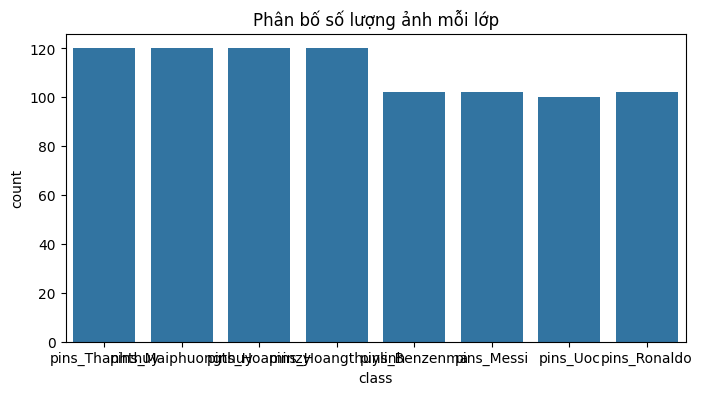

In [2]:
def load_and_process_data(data_dir):
    image_dir = Path(data_dir)
    filepaths = list(image_dir.glob(r'**/*.jpg')) + list(image_dir.glob(r'**/*.png')) + list(image_dir.glob(r'**/*.jpeg'))

    if not filepaths:
        print(f"Không tìm thấy ảnh nào trong {data_dir}")
        return None
    labels = [os.path.split(os.path.split(filepath)[0])[1] for filepath in filepaths]

    filepaths = pd.Series(filepaths, name='filename').astype(str)
    labels = pd.Series(labels, name='class')
    df = pd.concat([filepaths, labels], axis=1)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

print("Tải dữ liệu...")
df = load_and_process_data(DATA_DIR)

if df is not None:
    print(f"Số ảnh tìm thấy: {len(df)}")
    print(f"Các lớp: {df['class'].unique()}")

    plt.figure(figsize=(8, 4))
    sns.countplot(x=df['class'])
    plt.title("Phân bố số lượng ảnh mỗi lớp")
    plt.show()
else:
    raise ValueError("Không có dữ liệu.")

## 3. Xây dựng Kiến trúc Mô hình (Model Architecture)

Hàm `build_vgg16_model` định nghĩa kiến trúc mạng CNN dựa trên kỹ thuật **Transfer Learning** (Học chuyển giao):

1.  **Backbone VGG16 (Feature Extractor):**
    * Sử dụng mạng VGG16 đã huấn luyện trước trên tập **ImageNet** để tận dụng các đặc trưng thị giác cấp cao.
    * Thiết lập `include_top=False` để loại bỏ lớp phân loại gốc (1000 lớp của ImageNet).
    * **Đóng băng trọng số (`trainable = False`):** Giữ nguyên các tham số của các lớp tích chập (Convolutional base), chỉ huấn luyện các lớp mới thêm vào.

2.  **Lớp Gộp (Pooling Strategy):**
    * **`GlobalAveragePooling2D`:** Được sử dụng thay cho `Flatten`. Kỹ thuật này tính trung bình không gian của các feature map, giúp giảm mạnh số lượng tham số cần huấn luyện và hạn chế hiện tượng Overfitting.

3.  **Lớp Phân loại Tùy chỉnh (Classifier Head):**
    * **`Dense (256)`:** Lớp ẩn để học các đặc trưng phi tuyến tính cụ thể của bộ dữ liệu mới.
    * **`BatchNormalization`:** Chuẩn hóa dữ liệu giữa các lớp, giúp mô hình hội tụ nhanh và ổn định hơn.
    * **`Dropout (0.5)`:** Kỹ thuật Regularization, tắt ngẫu nhiên 50% nơ-ron trong quá trình train để ngăn model "học vẹt" (overfitting).
    * **Output Layer:** Sử dụng hàm kích hoạt **`Softmax`** để trả về xác suất dự đoán cho từng lớp (Multi-class classification).

4.  **Biên dịch (Compilation):**
    * Sử dụng Optimizer **`Adam`** với tốc độ học đã cấu hình và hàm loss **`categorical_crossentropy`** (tiêu chuẩn cho bài toán phân loại đa lớp one-hot encoding).

In [3]:
def build_vgg16_model(num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Định nghĩa hàm build model VGG16.")

Định nghĩa hàm build model VGG16.


## 4. Huấn luyện và Đánh giá Chéo (Training Loop & Cross-Validation)

Đây là thành phần quan trọng nhất của quy trình, thực hiện chiến lược **Stratified K-Fold Cross-Validation** (k=5) để đánh giá hiệu năng mô hình một cách khách quan:

1.  **Cơ chế Phân chia dữ liệu (Stratified K-Fold):**
    *
    * Chia tập dữ liệu thành **5 phần (folds)**. Trong mỗi vòng lặp, 4 phần được dùng để train và 1 phần để validation.
    * **Tính chất Stratified:** Đảm bảo tỉ lệ các lớp trong mỗi fold giống hệt tỉ lệ của tập dữ liệu gốc, tránh việc một fold chỉ toàn chứa một loại ảnh (bias).

2.  **Tăng cường Dữ liệu (Data Augmentation):**
    * Áp dụng các kỹ thuật biến đổi ảnh **chỉ trên tập Train**: xoay (rotation), dịch chuyển (shift), cắt (shear), zoom và lật ngang (flip).
    * **Mục đích:** Tạo ra các biến thể đa dạng của ảnh gốc, giúp mô hình học được các đặc trưng bất biến và giảm thiểu Overfitting.
    * *Lưu ý:* Tập Validation được giữ nguyên bản (chỉ qua `preprocess_input`) để đánh giá trung thực.

3.  **Cơ chế Huấn luyện (Training Flow):**
    * **Khởi tạo lại Model:** Tại mỗi fold, một mô hình VGG16 mới hoàn toàn được khởi tạo để đảm bảo tính độc lập giữa các lần đánh giá.
    * **Hệ thống Callbacks tối ưu:**
        * `ModelCheckpoint`: Chỉ lưu lại trọng số (weights) có độ chính xác cao nhất trên tập Val.
        * `EarlyStopping`: Tự động dừng huấn luyện nếu `val_loss` không cải thiện sau 7 epochs (tiết kiệm thời gian).
        * `ReduceLROnPlateau`: Giảm learning rate đi 5 lần nếu mô hình gặp khó khăn trong việc hội tụ.

4.  **Tổng hợp Kết quả:**
    * Sau mỗi fold, kết quả dự đoán (`y_pred`) và nhãn thực (`y_true`) được tích lũy vào một danh sách tổng.
    * Sử dụng `K.clear_session()` để giải phóng VRAM GPU sau mỗi vòng lặp, ngăn chặn lỗi tràn bộ nhớ (OOM).

In [4]:
acc_per_fold = []
loss_per_fold = []
histories = []
all_true_labels = []
all_predictions = []

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_no = 1

print(f"\n Bắt đầu")

global_train_gen = None

for train_index, val_index in skf.split(df['filename'], df['class']):
    print(f"\n{'='*40}")
    print(f"FOLD {fold_no}/{NUM_FOLDS}")
    print(f"{'='*40}")

    train_data = df.iloc[train_index]
    val_data = df.iloc[val_index]

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_gen = train_datagen.flow_from_dataframe(
        train_data, x_col='filename', y_col='class',
        target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True
    )

    if fold_no == 1:
        global_train_gen = train_gen

    val_gen = val_datagen.flow_from_dataframe(
        val_data, x_col='filename', y_col='class',
        target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False
    )

    model = build_vgg16_model(num_classes=len(train_gen.class_indices))

    checkpoint_path = os.path.join(MODELS_DIR, f"vgg16_best_fold_{fold_no}.h5")
    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        train_gen, epochs=EPOCHS,
        validation_data=val_gen, callbacks=callbacks, verbose=1
    )
    histories.append(history)

    scores = model.evaluate(val_gen, verbose=0)
    print(f'Kết quả Fold {fold_no}: Accuracy = {scores[1]*100:.2f}%')
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    val_gen.reset()
    preds = model.predict(val_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes

    all_true_labels.extend(y_true)
    all_predictions.extend(y_pred)

    K.clear_session()
    fold_no += 1


 Bắt đầu

FOLD 1/5
Found 708 validated image filenames belonging to 8 classes.
Found 178 validated image filenames belonging to 8 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.4336 - loss: 1.8637 
Epoch 1: val_accuracy improved from -inf to 0.79213, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_1.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 490s 21s/step - accuracy: 0.4414 - loss: 1.8360 - val_accuracy: 0.7921 - val_loss: 0.6449 - learning_rate: 0.0010
Epoch 2/50
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.8538 - loss: 0.4853
Epoch 2: val_accuracy improved from 0.79213 to 0.95506, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_1.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 660ms/step - accuracy: 0.8557 - loss: 0.4763 - val_accuracy: 0.9551 - val_loss: 0.2241 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9453 - loss: 0.2092
Epoch 3: val_accuracy improved from 0.95506 to 0.96067, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_1.h5


...

23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 674ms/step - accuracy: 0.8844 - loss: 0.3368 - val_accuracy: 0.9209 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9536 - loss: 0.1999
Epoch 3: val_accuracy improved from 0.92090 to 0.95480, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_5.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 657ms/step - accuracy: 0.9536 - loss: 0.1992 - val_accuracy: 0.9548 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9359 - loss: 0.1950
Epoch 4: val_accuracy improved from 0.95480 to 0.96610, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_5.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 699ms/step - accuracy: 0.9365 - loss: 0.1934 - val_accuracy: 0.9661 - val_loss: 0.1378 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9529 - loss: 0.1726
Epoch 5: val_accuracy improved from 0.96610 to 0.97175, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_5.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 651ms/step - accuracy: 0.9531 - loss: 0.1716 - val_accuracy: 0.9718 - val_loss: 0.1156 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9855 - loss: 0.1074
Epoch 6: val_accuracy improved from 0.97175 to 0.98305, saving model to /content/drive/MyDrive/AI_VGG16_Classifier/models/vgg16_best_fold_5.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 646ms/step - accuracy: 0.9852 - loss: 0.1078 - val_accuracy: 0.9831 - val_loss: 0.1100 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.9499 - loss: 0.1682
Epoch 7: val_accuracy did not improve from 0.98305
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 674ms/step - accuracy: 0.9506 - loss: 0.1658 - val_accuracy: 0.9831 - val_loss: 0.1056 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9713 - loss: 0.1148
Epoch 8: val_accuracy did not improve from 0.98305
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 604ms/step - accuracy: 0.9712 - loss: 0.1151 - val_accuracy: 0.9831 - val_loss: 0.1031 - learning_rate: 0.0010
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.9768 - loss: 0.0870
Epoch 9: val_accuracy did not improve from 0.98305
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 602ms/step - accuracy: 0.9769 - loss: 0.0867 - val_accuracy: 0.9718 - val_loss: 0.1151 - learning_rate: 0.0010
Epoch 10/50
23/23 ━━━

## 5. Tổng hợp Kết quả & Trực quan hóa (Results & Visualization)

Cell cuối cùng thực hiện việc tổng hợp số liệu từ 5 lần chạy (folds) và vẽ biểu đồ đánh giá toàn diện:

1.  **Chỉ số Tổng hợp (Overall Metrics):**
    * Tính toán **Độ chính xác trung bình (Mean Accuracy)** và độ lệch chuẩn (Standard Deviation) trên toàn bộ 5 folds.
    * *Ý nghĩa:* Cho biết hiệu năng thực tế và độ ổn định của mô hình (độ lệch chuẩn thấp chứng tỏ model hoạt động ổn định, không phụ thuộc vào cách chia dữ liệu).

2.  **Báo cáo Chi tiết (Classification Report):**
    * Xuất bảng thống kê các chỉ số **Precision, Recall, và F1-Score** cho từng lớp cụ thể.
    * Giúp phát hiện các lớp mà mô hình đang "học yếu" hoặc bị nhầm lẫn nhiều nhất.

3.  **Ma trận Nhầm lẫn (Confusion Matrix):**
    *
    * Sử dụng Heatmap để trực quan hóa sự nhầm lẫn giữa các lớp (Tổng hợp từ cả 5 folds).
    * Trục tung là nhãn thực tế, trục hoành là dự đoán. Các giá trị nằm ngoài đường chéo chính đại diện cho các mẫu bị phân loại sai (Misclassification).

4.  **Đồ thị Lịch sử Huấn luyện (Training History):**
    *
    * Vẽ 4 biểu đồ đường so sánh Accuracy và Loss của tập Train vs Validation qua từng Epoch.
    * **Mục đích:** Kiểm tra trực quan hiện tượng **Overfitting** (khi đường Train đi lên nhưng Val đi ngang/xuống) và đánh giá tốc độ hội tụ của mô hình.


TỔNG KẾT VGG16 - 5 FOLD
Độ chính xác trung bình: 98.31% (+/- 0.62%)

--- CLASSIFICATION REPORT ---
                    precision    recall  f1-score   support

     pins_Benzenma       1.00      1.00      1.00       102
     pins_Hoaminzy       0.96      0.99      0.98       120
pins_Hoangthuylinh       0.98      0.97      0.97       120
pins_Maiphuongthuy       0.95      0.98      0.97       120
        pins_Messi       0.99      1.00      1.00       102
      pins_Ronaldo       1.00      0.99      1.00       102
    pins_Thanhthuy       0.99      0.94      0.97       120
          pins_Uoc       1.00      1.00      1.00       100

          accuracy                           0.98       886
         macro avg       0.98      0.98      0.98       886
      weighted avg       0.98      0.98      0.98       886



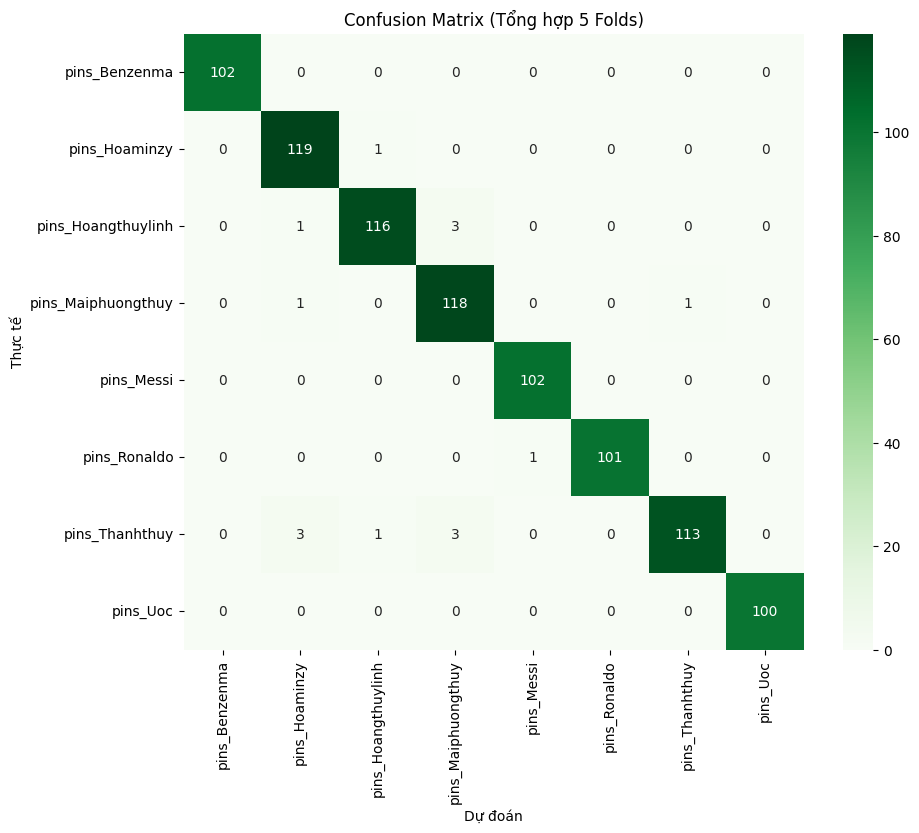

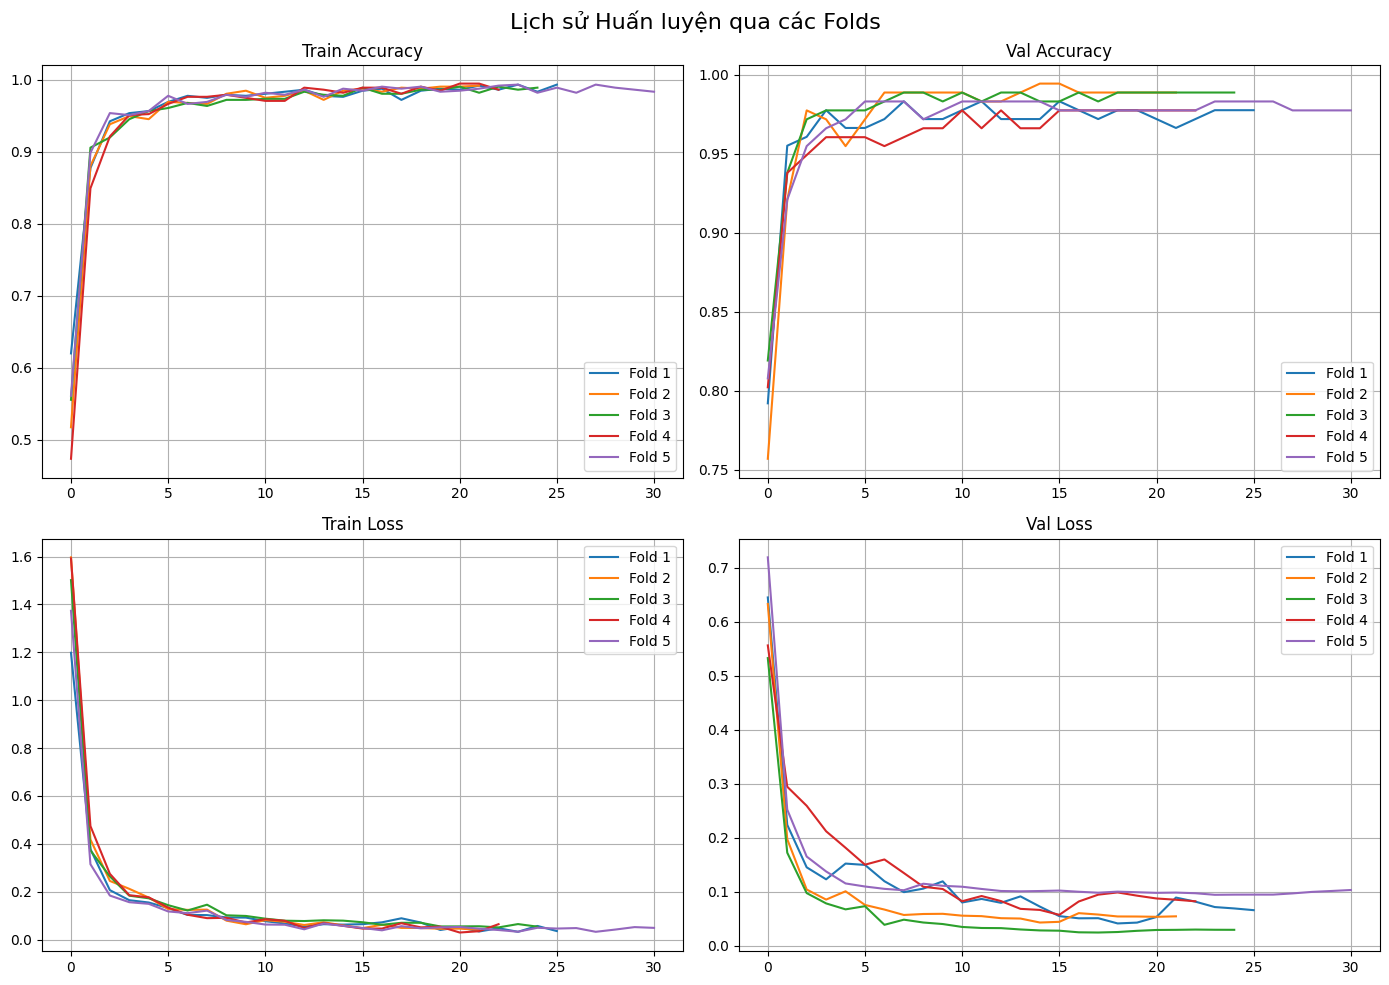

In [5]:
def plot_results(histories, acc_per_fold, all_true_labels, all_predictions, class_names):
    print("\n" + "="*50)
    print("TỔNG KẾT VGG16 - 5 FOLD")
    print("="*50)
    print(f"Độ chính xác trung bình: {np.mean(acc_per_fold):.2f}% (+/- {np.std(acc_per_fold):.2f}%)")

    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(all_true_labels, all_predictions, target_names=class_names))

    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(all_true_labels, all_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Tổng hợp 5 Folds)')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

    if histories:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Lịch sử Huấn luyện qua các Folds', fontsize=16)

        for i, h in enumerate(histories):
            axes[0, 0].plot(h.history['accuracy'], label=f'Fold {i+1}')
            axes[0, 1].plot(h.history['val_accuracy'], label=f'Fold {i+1}')
            axes[1, 0].plot(h.history['loss'], label=f'Fold {i+1}')
            axes[1, 1].plot(h.history['val_loss'], label=f'Fold {i+1}')

        titles = ['Train Accuracy', 'Val Accuracy', 'Train Loss', 'Val Loss']
        for ax, title in zip(axes.flat, titles):
            ax.set_title(title)
            ax.legend()
            ax.grid(True)
        plt.tight_layout()
        plt.show()

if len(acc_per_fold) > 0 and global_train_gen is not None:
    class_names = list(global_train_gen.class_indices.keys())
    plot_results(histories, acc_per_fold, all_true_labels, all_predictions, class_names)
else:
    print("Lỗi")